In [1]:
import numpy as np
import math
import cmath
from math import ceil,floor
import pickle
from scipy.integrate import quad
from itertools import repeat,product
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter, FormatStrFormatter
import sys
import os
import h5py
import multiprocess
from multiprocess import Pool
from matplotlib.lines import Line2D
from matplotlib.colors import LogNorm
from scipy.ndimage import gaussian_filter
from scipy.optimize import minimize_scalar,root,root_scalar,brentq
from scipy.interpolate import InterpolatedUnivariateSpline
import statistics
#Add src directory to the path so python can find the files
from scipy.integrate import quad
from matplotlib import rc
rc('font',**{'family':'sans-serif','sans-serif':['Helvetica']})
rc('text', usetex=True)
font = {'family' : 'normal',
    'weight' : 'bold',
        'size'   : 16}
rc('font', **font)

In [24]:
f = h5py.File("/mt/user-batch/dpasari/results_z3_b0/gradient_energy_snapshot_scalar.h5", "r")

grp = f["E_S_G_0"]   # or E_S_K_1

times = sorted(grp.keys(), key=lambda s: float(s))
print(times)

arr = grp["2."][:]   # load into numpy array
print(arr.shape, arr.min(), arr.max())

['0.', '2.', '4.', '6.', '8.', '10.', '12.', '14.', '16.', '18.', '20.', '22.', '24.', '26.', '28.']
(1024, 1024, 1024) 5.00874999330829e-15 2.227858542637693e-08


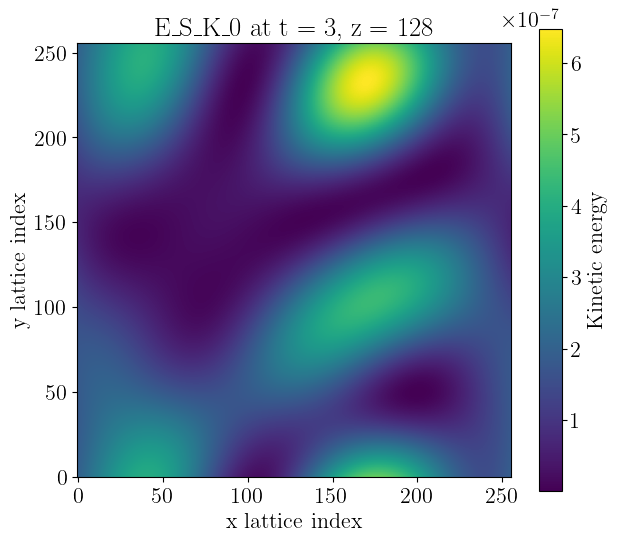

In [27]:
z0 = 128
slice_xy = arr[:, :, z0]

plt.figure(figsize=(7,6))
plt.imshow(slice_xy.T, origin="lower", cmap="viridis", aspect="equal")
plt.colorbar(label="Kinetic energy")
plt.xlabel("x lattice index")
plt.ylabel("y lattice index")
plt.title(f"E_S_K_0 at t = 3, z = {z0}")
plt.show()

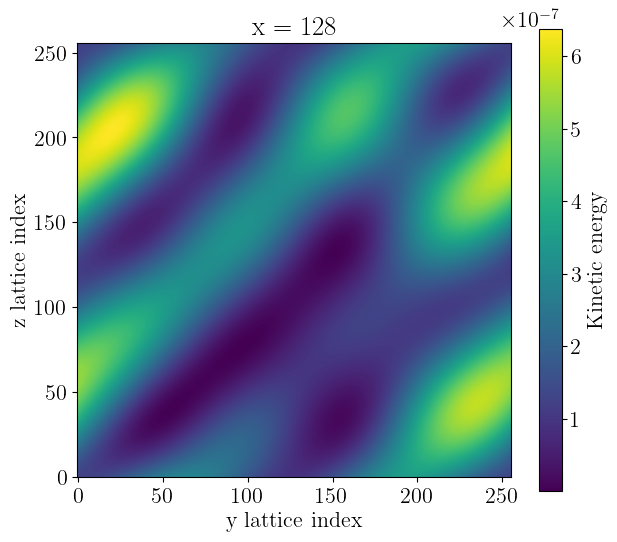

In [28]:
x0 = 128
plt.figure(figsize=(7,6))
plt.imshow(arr[x0, :, :].T, origin="lower", cmap="viridis", aspect="equal")
plt.colorbar(label="Kinetic energy")
plt.xlabel("y lattice index")
plt.ylabel("z lattice index")
plt.title(f"x = {x0}")
plt.show()

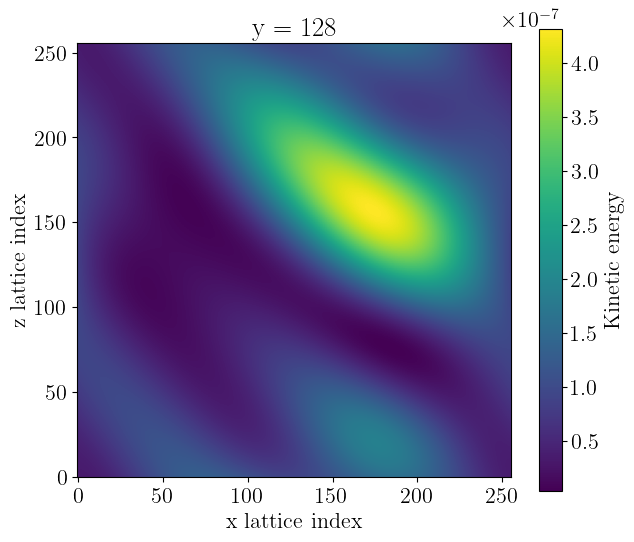

In [29]:
y0 = 128
plt.figure(figsize=(7,6))
plt.imshow(arr[:, y0, :].T, origin="lower", cmap="viridis", aspect="equal")
plt.colorbar(label="Kinetic energy")
plt.xlabel("x lattice index")
plt.ylabel("z lattice index")
plt.title(f"y = {y0}")
plt.show()

In [30]:
samples = []
for t in times:
    arr = grp[t][:]
    samples.append(arr.ravel())

all_vals = np.concatenate(samples)

vmin = np.percentile(all_vals, 1)
vmax = np.percentile(all_vals, 99.5)

print(vmin, vmax)

4.1745059487150137e-10 0.0005594421352651865


Global fixed scale: 4.119145403075997e-09 0.0011599730258097707


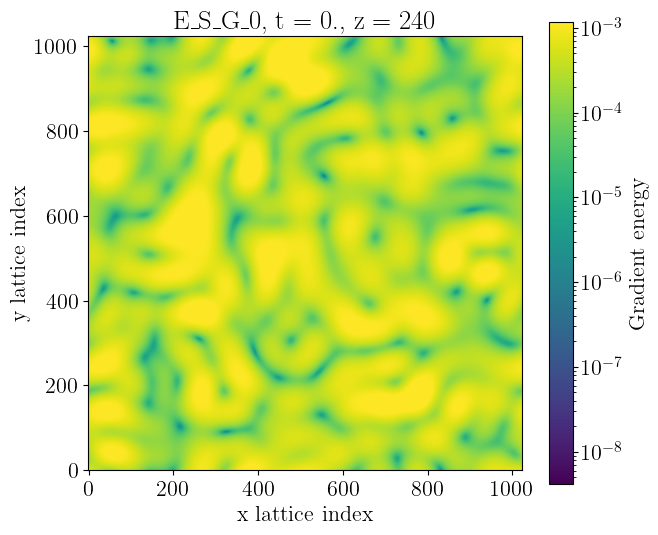

In [33]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib.colors import LogNorm

f = h5py.File("/mt/user-batch/dpasari/results_z3_b_0p01/gradient_energy_snapshot_scalar.h5", "r")
grp = f["E_S_G_0"]
times = sorted(grp.keys(), key=lambda s: float(s))

z0 = 240

# -----------------------------------
# compute one global scale
# -----------------------------------
samples = []
for t in times:
    arr = grp[t][:, :, z0]
    positive = arr[arr > 0]
    if positive.size > 0:
        samples.append(positive.ravel())

all_vals = np.concatenate(samples)

vmin = np.percentile(all_vals, 1)
vmax = np.percentile(all_vals, 99.5)

print("Global fixed scale:", vmin, vmax)

# -----------------------------------
# animate
# -----------------------------------
fig, ax = plt.subplots(figsize=(7, 6))

first = grp[times[0]][:, :, z0]

im = ax.imshow(first.T,
               origin="lower",
               cmap="viridis",
               norm=LogNorm(vmin=vmin, vmax=vmax),
               animated=True)

plt.colorbar(im, ax=ax, label="Gradient energy")
title = ax.set_title(f"E_S_G_0, t = {times[0]}, z = {z0}")
ax.set_xlabel("x lattice index")
ax.set_ylabel("y lattice index")
plt.show()

def update(i):
    t = times[i]
    data = grp[t][:, :, z0]
    im.set_array(data.T)
    title.set_text(f"E_S_G_0, t = {t}, z = {z0}")
    return im, title

ani = FuncAnimation(fig, update, frames=len(times), interval=400, blit=False)
ani.save("slice_animation_b_0p01.gif", writer="pillow", dpi=120,fps = 1)
plt.show()

Global fixed scale: 3.941526994394659e-09 0.0013927657274032696


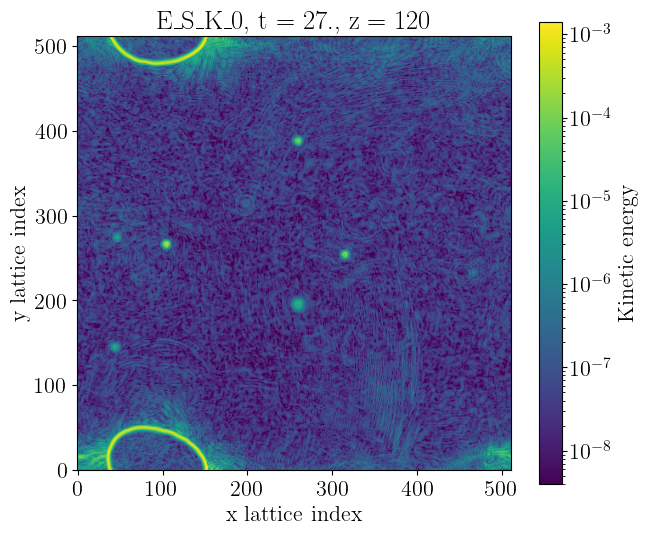

In [120]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib.colors import LogNorm

f = h5py.File("/mt/user-batch/dpasari/results_z3_b_0p1_PRS/gradient_energy_snapshot_scalar.h5", "r")
grp = f["E_S_G_0"]
times = sorted(grp.keys(), key=lambda s: float(s))

z0 = 120

# -----------------------------------
# compute one global scale
# -----------------------------------
samples = []
for t in times:
    arr = grp[t][:, :, z0]
    positive = arr[arr > 0]
    if positive.size > 0:
        samples.append(positive.ravel())

all_vals = np.concatenate(samples)

vmin = np.percentile(all_vals, 1)
vmax = np.percentile(all_vals, 99.5)

print("Global fixed scale:", vmin, vmax)

# -----------------------------------
# animate
# -----------------------------------
fig, ax = plt.subplots(figsize=(7, 6))

first = grp[times[0]][:, :, z0]

im = ax.imshow(first.T,
               origin="lower",
               cmap="viridis",
               norm=LogNorm(vmin=vmin, vmax=vmax),
               animated=True)

plt.colorbar(im, ax=ax, label="Kinetic energy")
title = ax.set_title(f"E_S_K_0, t = {times[0]}, z = {z0}")
ax.set_xlabel("x lattice index")
ax.set_ylabel("y lattice index")

def update(i):
    t = times[i]
    data = grp[t][:, :, z0]
    im.set_array(data.T)
    title.set_text(f"E_S_K_0, t = {t}, z = {z0}")
    return im, title

ani = FuncAnimation(fig, update, frames=len(times), interval=400, blit=False)
ani.save("slice_animation_fixed.gif", writer="pillow", dpi=120,fps = 4)
plt.show()

Global fixed scale: 3.2974037892354042e-09 0.0018534517023458012


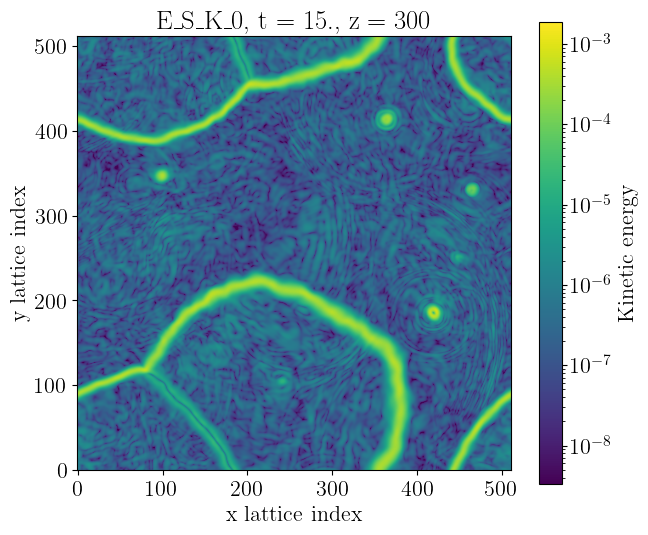

In [13]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib.colors import LogNorm

f = h5py.File("/mt/user-batch/dpasari/results_z3_b_0p1_PRS/gradient_energy_snapshot_scalar.h5", "r")
grp = f["E_S_G_0"]
times = sorted(grp.keys(), key=lambda s: float(s))


for i in range(1):
    z0 = 300

    # -----------------------------------
    # compute one global scale
    # -----------------------------------
    samples = []
    for t in times:
        arr = grp[t][:, :, z0]
        positive = arr[arr > 0]
        if positive.size > 0:
            samples.append(positive.ravel())

    all_vals = np.concatenate(samples)

    vmin = np.percentile(all_vals, 1)
    vmax = np.percentile(all_vals, 99.5)

    print("Global fixed scale:", vmin, vmax)

    # -----------------------------------
    # animate
    # -----------------------------------
    fig, ax = plt.subplots(figsize=(7, 6))

    first = grp[times[0]][:, :, z0]

    im = ax.imshow(first.T,
                origin="lower",
                cmap="viridis",
                norm=LogNorm(vmin=vmin, vmax=vmax),
                animated=True)

    plt.colorbar(im, ax=ax, label="Kinetic energy")
    title = ax.set_title(f"E_S_K_0, t = {times[0]}, z = {z0}")
    ax.set_xlabel("x lattice index")
    ax.set_ylabel("y lattice index")

    def update(i):
        t = times[i]
        data = grp[t][:, :, z0]
        im.set_array(data.T)
        title.set_text(f"E_S_K_0, t = {t}, z = {z0}")
        return im, title

    ani = FuncAnimation(fig, update, frames=len(times), interval=400, blit=False)
    ani.save(f"slice_animation_fixed_z_0p1_{z0}.gif", writer="pillow", dpi=120,fps = 1)
    plt.show()

In [72]:
 pip install imageio

     |████████████████████████████████| 317 kB 5.6 MB/s            
You should consider upgrading via the '/mt/home/dpasari/CosmoLatticeDomainWalls-main/Z3_env/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [24]:
import h5py
import numpy as np
import pyvista as pv

f = h5py.File("/mt/user-batch/dpasari/results_z3/gradient_energy_snapshot_scalar.h5", "r")
grp = f["E_S_G_0"]
times = sorted(grp.keys(), key=lambda s: float(s))

ds = 4  # downsample factor

# ---------------------------------
# choose a fixed contour level
# based on the smallest frame max
# ---------------------------------
frame_maxes = []
for t in times:
    arr = grp[t][:][::ds, ::ds, ::ds]
    frame_maxes.append(arr.max())

frame_maxes = np.array(frame_maxes)

print("Frame maxima:")
for t, m in zip(times, frame_maxes):
    print(t, m)

level = 0.2 * frame_maxes.min()
print("Fixed contour level =", level)

# ---------------------------------
# setup grid
# ---------------------------------
arr0 = grp[times[0]][::ds, ::ds, ::ds]

grid = pv.ImageData()
grid.dimensions = arr0.shape
grid.origin = (0, 0, 0)
grid.spacing = (ds, ds, ds)

plotter = pv.Plotter(off_screen=True)
plotter.open_gif("kinetic_contour.gif")

for t in times:
    arr = grp[t][:][::ds, ::ds, ::ds]
    grid.point_data["K"] = arr.flatten(order="F")

    contour = grid.contour(isosurfaces=[level], scalars="K")

    plotter.clear()
    if contour.n_points > 0:
        plotter.add_mesh(contour, opacity=0.6)
    else:
        plotter.add_text("No contour in this frame", font_size=12)

    plotter.add_text(f"E_S_G_0, t = {t}", font_size=12)
    plotter.add_axes()
    plotter.write_frame()
    plotter.write_frame()
    plotter.write_frame()
    plotter.write_frame()

plotter.close()

Frame maxima:
0. 0.00017924563240645505
2. 5.186393760527578e-07
4. 2.242643239480274e-07
6. 3.740928227754595e-08
8. 2.3679224662061213e-08
10. 3.673123416724965e-09
12. 1.0864252525319514e-08
14. 5.645561884494501e-09
16. 1.4248815575013724e-08
18. 1.442565005529926e-07
20. 2.816169817095865e-06
22. 0.00010061231989645213
24. 0.0014791177093450305
26. 0.0013761865102610003
28. 0.0013452287466785417
Fixed contour level = 7.34624683344993e-10


In [76]:
frame_maxes = []
for t in times:
    arr = grp[t][:][::4, ::4, ::4]
    frame_maxes.append(arr.max())

frame_maxes = np.array(frame_maxes)

print("frame maxima =", frame_maxes)
print("min frame max =", frame_maxes.min())
print("max frame max =", frame_maxes.max())

level = 0.2 * frame_maxes.min()
print("Using fixed contour level =", level)

frame maxima = [5.19061543e-04 1.39862634e-06 1.61858409e-07 1.52158698e-08
 5.84261870e-09 4.91695662e-08 3.58430349e-06 3.08889508e-04
 7.10450560e-04 7.24796544e-04]
min frame max = 5.842618698732754e-09
max frame max = 0.0007247965435259543
Using fixed contour level = 1.168523739746551e-09


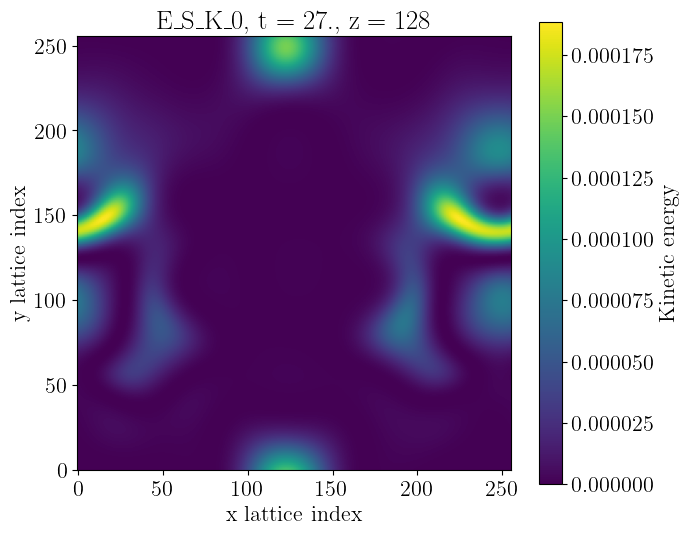

In [66]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

z0 = 128

fig, ax = plt.subplots(figsize=(7,6))
im = ax.imshow(grp[times[0]][:, :, z0].T,
               origin="lower",
               cmap="viridis",
               vmin=vmin, vmax=vmax,
               animated=True)
cbar = plt.colorbar(im, ax=ax, label="Kinetic energy")
title = ax.set_title("")

ax.set_xlabel("x lattice index")
ax.set_ylabel("y lattice index")

def update(i):
    t = times[i]
    data = grp[t][:, :, z0]
    im.set_array(data.T)
    im.set_clim(vmin=np.min(data), vmax=np.max(data))
    title.set_text(f"E_S_K_0, t = {t}, z = {z0}")
    return im, title

ani = FuncAnimation(fig, update, frames=len(times), interval=400, blit=False)
ani.save("slice_animation.gif", writer="pillow", dpi=150)
plt.show()

In [58]:
file_path_dir = "/mt/user-batch/dpasari/results_z3_b_0p1_Hnorm_k1/"

In [59]:
# Path to the file
file_path = f"{file_path_dir}average_energies.txt"

# Initialize 7 arrays
eta, Ek_1,Ek_2,Eg_1,Eg_2,Ev_1,Ev_2,Ev_3, E_tot, scal = [], [], [], [], [], [], [],[],[],[]

# Read and process the file
try:
    with open(file_path, 'r') as file:
        # Read all lines
        lines = file.readlines()
    # Split lines into 7 columns and populate arrays
    for line in lines:
        # Split by whitespace
        columns = line.split()
        if len(columns) != 10:
            raise ValueError(f"Line does not have exactly 7 columns: {line.strip()}")

        # Append each column to its respective array
        eta.append(float(columns[0]))
        Ek_1.append(float(columns[1]))
        Ek_2.append(float(columns[2]))
        Eg_1.append(float(columns[3]))
        Eg_2.append(float(columns[4]))
        Ev_1.append(float(columns[5]))
        Ev_2.append(float(columns[6]))
        Ev_3.append(float(columns[7]))
        E_tot.append(float(columns[8]))
        scal.append(float(columns[9]))


except FileNotFoundError:
    print(f"File not found: {file_path}")
except Exception as e:
    print(f"An error occurred: {e}")

scal = np.asarray(scal)
Eg_1 = np.asarray(Eg_1)
Eg_2 = np.asarray(Eg_2)
Ev_1 = np.asarray(Ev_1)
Ev_2 = np.asarray(Ev_2)
Ev_3 = np.asarray(Ev_3)

In [60]:
len(scal),len(eta)

(529, 529)

In [61]:
# Path to the file
file_path = f"{file_path_dir}average_scalar_1.txt"


# Initialize 7 arrays
eta, phi, phi_prime, phi2, phi_prime2, rms_phi, rms_phi_prime = [], [], [], [], [], [], []

# Read and process the file
try:
    with open(file_path, 'r') as file:
        # Read all lines
        lines = file.readlines()
    # Split lines into 7 columns and populate arrays
    for line in lines:
        # Split by whitespace
        columns = line.split()
        if len(columns) != 7:
            raise ValueError(f"Line does not have exactly 7 columns: {line.strip()}")

        # Append each column to its respective array
        eta.append(float(columns[0]))
        phi.append(float(columns[1]))
        phi_prime.append(float(columns[2]))
        phi2.append(float(columns[3]))
        phi_prime2.append(float(columns[4]))
        rms_phi.append(float(columns[5]))
        rms_phi_prime.append(float(columns[6]))

except FileNotFoundError:
    print(f"File not found: {file_path}")
except Exception as e:
    print(f"An error occurred: {e}")

eta = np.asarray(eta)
phi = np.asarray(phi)
phi2 = np.asarray(phi2)

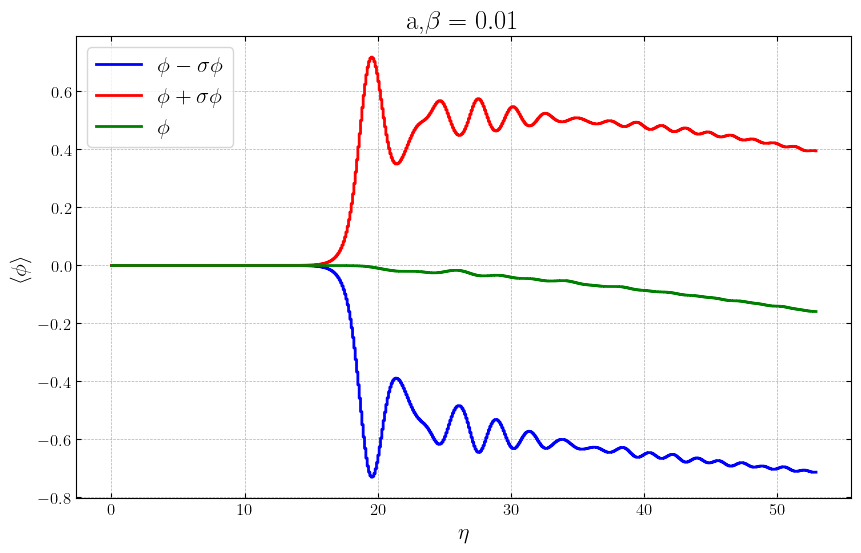

In [62]:

fig, ax = plt.subplots(figsize=(10, 6))
ax.step(eta,phi-(phi2-phi**2), color='blue', linewidth=2,label=r"$\phi-\sigma \phi$")
ax.step(eta,phi+(phi2-phi**2), color='red', linewidth=2, label = r"$\phi+\sigma \phi$")
ax.step(eta,phi, color='green', linewidth=2,label = r"$\phi$")


"""plt.axvline(x=max_energy_e, color='b', linestyle='--', label=r'Max Energy $\nu_e$ = ' + f'{max_energy_e:.2f}')
plt.axhline(y=max_flux_e, color='b', linestyle='--', label=r'Max Flux $\nu_e$ = '+ f'{max_flux_e}')

plt.axvline(x=max_energy_mu, color='r', linestyle='--', label=r'Max Energy $\nu_{\mu}$ = ' + f'{max_energy_mu:.2f}')
plt.axhline(y=max_flux_mu, color='r', linestyle='--', label=r'Max Flux $\nu_{\mu}$ = '+ f'{max_flux_mu}')
"""

# Title and labels
ax.set_ylabel(r'$\left<\phi\right>$', fontsize=16)

#ax.set_title(r"$\chi^2$ for $\nu_e$ events", fontsize=16)
ax.set_xlabel(r'$\eta$', fontsize=16)

# Ticks on all sides
ax.tick_params(axis='both', which='both', direction='in', top=True, right=True)

# Customize the grid
ax.grid(True, linestyle='--', linewidth=0.5)

plt.title(r"a,$\beta = 0.01$")
plt.legend()

# Customize tick labels
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)

# ax.set_xlim(0,10)
# ax.set_ylim(0,10)

# ax.set_yscale("log")

plt.show()


In [63]:
# Path to the file
file_path = f"{file_path_dir}average_scale_factor.txt"

# Initialize 7 arrays
eta, a,adot,H = [], [], [], []

# Read and process the file
try:
    with open(file_path, 'r') as file:
        # Read all lines
        lines = file.readlines()
    # Split lines into 7 columns and populate arrays
    for line in lines:
        # Split by whitespace
        columns = line.split()
        if len(columns) != 4:
            raise ValueError(f"Line does not have exactly 7 columns: {line.strip()}")

        # Append each column to its respective array
        eta.append(float(columns[0]))
        a.append(float(columns[1]))
        adot.append(float(columns[2]))
        H.append(float(columns[3]))


except FileNotFoundError:
    print(f"File not found: {file_path}")
except Exception as e:
    print(f"An error occurred: {e}")

a = np.asarray(a)
adot = np.asarray(adot)
H = np.asarray(H)
eta = np.asarray(eta)

In [64]:
# Path to the file
file_path = f"{file_path_dir}average_scalar_0.txt"


# Initialize 7 arrays
eta, phi, phi_prime, phi2, phi_prime2, rms_phi, rms_phi_prime = [], [], [], [], [], [], []

# Read and process the file
try:
    with open(file_path, 'r') as file:
        # Read all lines
        lines = file.readlines()
    # Split lines into 7 columns and populate arrays
    for line in lines:
        # Split by whitespace
        columns = line.split()
        if len(columns) != 7:
            raise ValueError(f"Line does not have exactly 7 columns: {line.strip()}")

        # Append each column to its respective array
        eta.append(float(columns[0]))
        phi.append(float(columns[1]))
        phi_prime.append(float(columns[2]))
        phi2.append(float(columns[3]))
        phi_prime2.append(float(columns[4]))
        rms_phi.append(float(columns[5]))
        rms_phi_prime.append(float(columns[6]))

except FileNotFoundError:
    print(f"File not found: {file_path}")
except Exception as e:
    print(f"An error occurred: {e}")

eta = np.asarray(eta)
phi = np.asarray(phi)
phi2 = np.asarray(phi2)

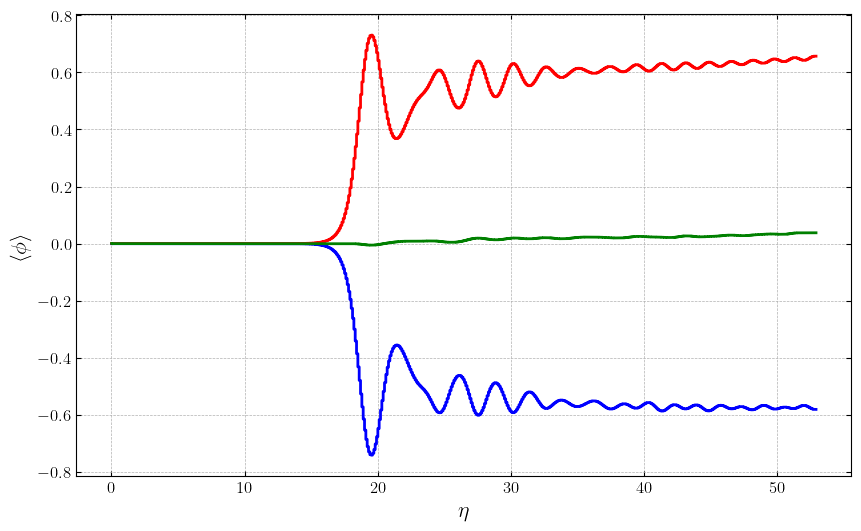

In [65]:

fig, ax = plt.subplots(figsize=(10, 6))
ax.step(eta,phi-(phi2-phi**2), color='blue', linewidth=2)
ax.step(eta,phi+(phi2-phi**2), color='red', linewidth=2)
ax.step(eta,phi, color='green', linewidth=2)


"""plt.axvline(x=max_energy_e, color='b', linestyle='--', label=r'Max Energy $\nu_e$ = ' + f'{max_energy_e:.2f}')
plt.axhline(y=max_flux_e, color='b', linestyle='--', label=r'Max Flux $\nu_e$ = '+ f'{max_flux_e}')

plt.axvline(x=max_energy_mu, color='r', linestyle='--', label=r'Max Energy $\nu_{\mu}$ = ' + f'{max_energy_mu:.2f}')
plt.axhline(y=max_flux_mu, color='r', linestyle='--', label=r'Max Flux $\nu_{\mu}$ = '+ f'{max_flux_mu}')
"""

# Title and labels
ax.set_ylabel(r'$\left<\phi\right>$', fontsize=16)

#ax.set_title(r"$\chi^2$ for $\nu_e$ events", fontsize=16)
ax.set_xlabel(r'$\eta$', fontsize=16)

# Ticks on all sides
ax.tick_params(axis='both', which='both', direction='in', top=True, right=True)

# Customize the grid
ax.grid(True, linestyle='--', linewidth=0.5)


# Customize tick labels
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)

# ax.set_xlim(0,20)
# ax.set_ylim(0,10)

# ax.set_yscale("log")

plt.show()


In [66]:
lside = 100
N_lat = 512
mu = 0.0547723
lambda1 = 0.003
lambda2 = 0.0516398
beta = lambda2*3/(8*lambda1)**0.5
g_beta = 3.62-2.12/(1+1.85*beta**1.81)
vev = mu/(2*lambda1)**0.5*(beta+(1+beta**2))
m_a = np.sqrt((9/np.sqrt(2))*lambda2*mu*vev)
del_dw = g_beta/m_a
# eta = eta[:-1]
eta[3/H>lside],eta[lside/N_lat>del_dw/a],beta

IndexError: boolean index did not match indexed array along axis 0; size of axis is 530 but size of corresponding boolean axis is 529

In [ ]:
# import numpy as np
# from scipy.sparse import diags, eye
# from scipy.sparse.linalg import factorized
# import matplotlib.pyplot as plt

# # ── Potential & derivatives (rescaled, dimensionless) ────────────────────────
# def V(p, q, b):
#     r2 = p**2 + q**2
#     return -0.5*r2 + 0.25*r2**2 - (2*b/3)*(p**3 - 3*p*q**2)

# def Vp(p, q, b):   # dV/dφ
#     return -p + p*(p**2 + q**2) - 2*b*(p**2 - q**2)

# def Vq(p, q, b):   # dV/dψ
#     return -q + q*(p**2 + q**2) + 4*b*p*q

# # ── Vacua ────────────────────────────────────────────────────────────────────
# def vacua(b):
#     rv = b + np.sqrt(b**2 + 1)
#     return np.array([rv, 0.]), np.array([-rv/2, rv*np.sqrt(3)/2])

# # ── Gradient-flow relaxation (IMEX: implicit Laplacian, explicit V') ─────────
# def relax(b, L=30, N=800, dt=1.0, tol=1e-11, maxiter=80000,
#           phi0=None, psi0=None):
#     """
#     Solves  ∂φ/∂t = φ'' - dV/dφ  →  0  via semi-implicit time stepping.
#     Matrix A = (I - dt·D²) is factorised once; each step is O(N).
#     """
#     v1, v2 = vacua(b)
#     Vv = V(*v1, b)
#     z  = np.linspace(-L, L, N)
#     dz = z[1] - z[0]

#     # Build A = I - dt·D² with Dirichlet rows at boundaries
#     e  = np.ones(N)
#     D2 = diags([e[1:], -2*e, e[1:]], [-1, 0, 1]) / dz**2
#     A  = (eye(N) - dt * D2).tolil()
#     A[0,  :] = 0;  A[0,  0]  = 1   # left  BC
#     A[-1, :] = 0;  A[-1, -1] = 1   # right BC
#     solve_A = factorized(A.tocsr())  # LU decomposition — done once

#     # Initial guess (tanh interpolation or warm-started from previous β)
#     if phi0 is None:
#         s   = 0.5 * (1 + np.tanh(5 * z / L))
#         phi = v1[0] * (1 - s) + v2[0] * s
#         psi = v1[1] * (1 - s) + v2[1] * s
#     else:
#         phi, psi = phi0.copy(), psi0.copy()

#     for _ in range(maxiter):
#         rp = phi - dt * Vp(phi, psi, b);  rp[0] = v1[0];  rp[-1] = v2[0]
#         rq = psi - dt * Vq(phi, psi, b);  rq[0] = v1[1];  rq[-1] = v2[1]

#         pn, qn = solve_A(rp), solve_A(rq)
#         err = max(np.max(np.abs(pn - phi)), np.max(np.abs(qn - psi)))
#         phi, psi = pn, qn
#         if err < tol:
#             break

#     # Wall tension integral
#     dp  = np.gradient(phi, z)
#     dq  = np.gradient(psi,  z)
#     eps = 0.5 * (dp**2 + dq**2) + V(phi, psi, b) - Vv
#     return np.trapz(eps, z), z, phi, psi

# # ── β-sweep with continuation (each β warm-starts from previous solution) ────
# betas     = np.linspace(0.05, 2.5, 50)
# f_vals    = []
# phi_prev  = psi_prev = None

# for b in betas:
#     f, z, phi, psi = relax(b, phi0=phi_prev, psi0=psi_prev)
#     phi_prev, psi_prev = phi.copy(), psi.copy()
#     f_vals.append(f)
#     print(f"β = {b:.3f}   f(β) = {f:.6f}")

# f_vals = np.array(f_vals)

# # ── Plot ─────────────────────────────────────────────────────────────────────
# fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# axes[0].plot(betas, f_vals, 'b-o', ms=4)
# axes[0].set_xlabel(r'$\beta = 3\lambda_2/\sqrt{8\lambda_1}$')
# axes[0].set_ylabel(r'$f(\beta)$   [dimensionless tension]')
# axes[0].set_title(r'$\sigma_{Z_3} = (\mu^3/\lambda_1)\,f(\beta)$')
# axes[0].grid(True, alpha=0.3)

# # show wall profile at last β
# b_ex = betas[-1]
# _, z, phi, psi = relax(b_ex, phi0=phi_prev, psi0=psi_prev)
# axes[1].plot(z, phi, label=r'$\tilde\phi$')
# axes[1].plot(z, psi, label=r'$\tilde\psi$')
# axes[1].set_xlabel(r'$\zeta = \mu z$')
# axes[1].set_title(f'Wall profile at β = {b_ex:.2f}')
# axes[1].legend(); axes[1].grid(True, alpha=0.3)

# plt.tight_layout()
# # plt.savefig('wall_tension.png', dpi=150)
# plt.show()

In [ ]:
# fig, ax = plt.subplots(1, 1, figsize=(12, 4))

# ax.plot(betas, f_vals, 'b-o', ms=4)
# ax.set_xlabel(r'$\beta $')
# ax.set_ylabel(r'$f(\beta)$')
# # axes[0].set_title(r'$\sigma_{Z_3} = (\mu^3/\lambda_1)\,f(\beta)$')
# ax.grid(True, alpha=0.3)

# # # show wall profile at last β
# # b_ex = betas[-1]
# # _, z, phi, psi = relax(b_ex, phi0=phi_prev, psi0=psi_prev)
# # axes[1].plot(z, phi, label=r'$\tilde\phi$')
# # axes[1].plot(z, psi, label=r'$\tilde\psi$')
# # axes[1].set_xlabel(r'$\zeta = \mu z$')
# # axes[1].set_title(f'Wall profile at β = {b_ex:.2f}')
# # axes[1].legend(); axes[1].grid(True, alpha=0.3)

# plt.tight_layout()
# ax.set_xscale("log")
# ax.set_yscale("log")
# # plt.savefig('wall_tension.png', dpi=150)
# plt.show()

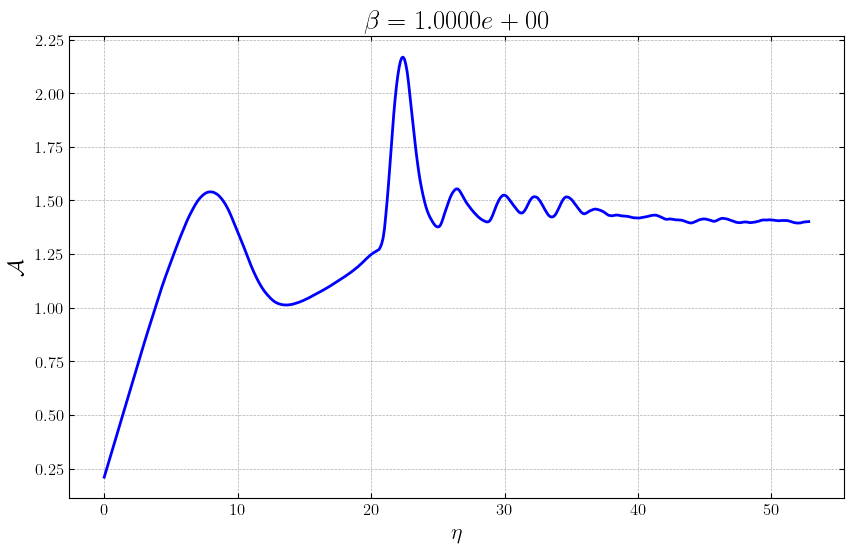

In [67]:

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(eta[:-1],scal/2/a/H, color='blue', linewidth=2,label=r"$\mu$")

# ax.plot(eta[:],Ev_1+Ev_2+Ev_3, color='blue', linewidth=2,label=r"$\mu$")
# ax.step(eta,Ev_2, color='red', linewidth=2,label=r"$\lambda_1$")
# ax.step(eta,Ev_3, color='green', linewidth=2,label=r"$\lambda_2$")


"""plt.axvline(x=max_energy_e, color='b', linestyle='--', label=r'Max Energy $\nu_e$ = ' + f'{max_energy_e:.2f}')
plt.axhline(y=max_flux_e, color='b', linestyle='--', label=r'Max Flux $\nu_e$ = '+ f'{max_flux_e}')

plt.axvline(x=max_energy_mu, color='r', linestyle='--', label=r'Max Energy $\nu_{\mu}$ = ' + f'{max_energy_mu:.2f}')
plt.axhline(y=max_flux_mu, color='r', linestyle='--', label=r'Max Flux $\nu_{\mu}$ = '+ f'{max_flux_mu}')
"""

# Title and labels
ax.set_ylabel(r'$\mathcal{A}$', fontsize=16)

#ax.set_title(r"$\chi^2$ for $\nu_e$ events", fontsize=16)
ax.set_xlabel(r'$\eta$', fontsize=16)

# Ticks on all sides
ax.tick_params(axis='both', which='both', direction='in', top=True, right=True)

# Customize the grid
ax.grid(True, linestyle='--', linewidth=0.5)
plt.title(fr'$\beta = {beta:.4e}$')

# ax.legend()

# Customize tick labels
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)

# ax.set_xlim(1,15)
# ax.set_ylim(0,10)

# ax.set_yscale("log")


plt.show()


In [293]:

# fig, ax = plt.subplots(figsize=(10, 6))
# ax.step(eta,phi-(phi2-phi**2), color='blue', linewidth=2)
# ax.step(eta,phi+(phi2-phi**2), color='red', linewidth=2)
# ax.step(eta,phi, color='green', linewidth=2)


# """plt.axvline(x=max_energy_e, color='b', linestyle='--', label=r'Max Energy $\nu_e$ = ' + f'{max_energy_e:.2f}')
# plt.axhline(y=max_flux_e, color='b', linestyle='--', label=r'Max Flux $\nu_e$ = '+ f'{max_flux_e}')

# plt.axvline(x=max_energy_mu, color='r', linestyle='--', label=r'Max Energy $\nu_{\mu}$ = ' + f'{max_energy_mu:.2f}')
# plt.axhline(y=max_flux_mu, color='r', linestyle='--', label=r'Max Flux $\nu_{\mu}$ = '+ f'{max_flux_mu}')
# """

# # Title and labels
# ax.set_ylabel(r'$\left<\phi\right>$', fontsize=16)

# #ax.set_title(r"$\chi^2$ for $\nu_e$ events", fontsize=16)
# ax.set_xlabel(r'$\eta$', fontsize=16)

# # Ticks on all sides
# ax.tick_params(axis='both', which='both', direction='in', top=True, right=True)

# # Customize the grid
# ax.grid(True, linestyle='--', linewidth=0.5)


# # Customize tick labels
# ax.tick_params(axis='x', labelsize=12)
# ax.tick_params(axis='y', labelsize=12)

# ax.set_xlim(0,20)
# # ax.set_ylim(0,10)

# # ax.set_yscale("log")

# plt.show()


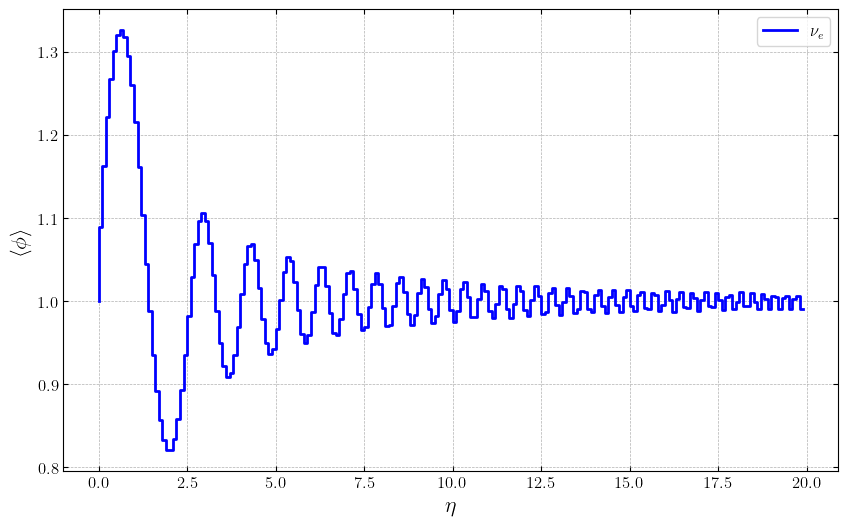

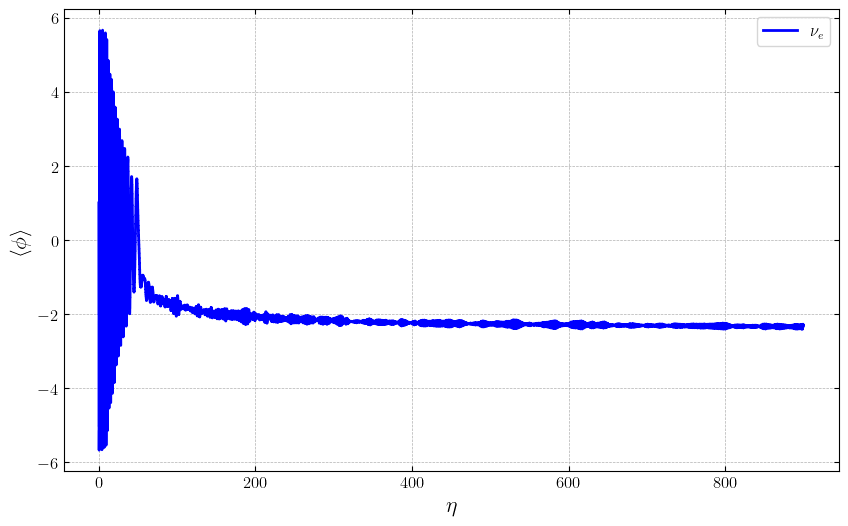


● Comparison of the two normalization factors

  They are not algebraically equivalent.

  Define $[ h_i \equiv \partial_i h,\quad a_i \equiv \partial_i a,\quad i\in{x,y,z}. ]$

  1) LaTeX expression (your formula)

  $[ F_{\text{LaTeX}}$

  $\sqrt{ \left(\frac{\sqrt{h_x^2+h_y^2+h_z^2}}{|h_x|+|h_y|+|h_z|}\right)^2 +
  \left(\frac{\sqrt{a_x^2+a_y^2+a_z^2}}{|a_x|+|a_y|+|a_z|}\right)^2 }. ]$

  2) ZNvacuumPhase expression (code)

  $[ F_{\text{ZN}}$

  $\frac{\sqrt{(h_x^2+h_y^2+h_z^2)+(a_x^2+a_y^2+a_z^2)}}
  {\sqrt{h_x^2+a_x^2}+\sqrt{h_y^2+a_y^2}+\sqrt{h_z^2+a_z^2}}. ]$

  Why they differ

   - LaTeX: normalize (h) and (a) separately, then combine.
   - ZN code: combine (h,a) per direction first, then normalize.

  These two orderings are different operations, so they are generally not equal.

  Practical note

  They can give similar numbers in special regimes (e.g. aligned directional gradients, nearly
  fixed radial mode, or after prefactor calibration), but this is an approximation, not an
  identity.